In [4]:
# ライブラリのインポート
import pandas as pd  # Pandasをインポート
import matplotlib.pyplot as plt  # Matplotlibをインポート
import matplotlib.dates as mdates  # Matplotlibの日付フォーマットをインポート
import japanize_matplotlib  # 日本語表示のためのパッケージをインポート
import numpy as np  # NumPyをインポート

# データ読み込み
sales_df = pd.read_csv("../data/raw/sales.csv") # 売上データの読み込み
detail_df = pd.read_csv("../data/raw/sale_details.csv") # 売上詳細データの読み込み
items_df = pd.read_csv("../data/raw/items.csv") # 商品データの読み込み



In [5]:
# 欠損値確認
print("=== 欠損値確認 ===")
print("sales_df:", sales_df.isnull().sum().sum(), "件") # 売上データの欠損値確認
print("detail_df:", detail_df.isnull().sum().sum(), "件") # 売上詳細データの欠損値確認
print("items_df:", items_df.isnull().sum().sum(), "件") # 商品データの欠損値確認


=== 欠損値確認 ===
sales_df: 0 件
detail_df: 0 件
items_df: 0 件


In [11]:
# 売上データの基本情報確認
print("\n=== sales_df ===")
print(sales_df.head()) # 売上データの先頭部分を表示
print(sales_df.info()) # 売上データの基本情報を表示
print(sales_df.describe()) # 売上データの基本統計量を表示




=== sales_df ===
   sale_id        date   time  temperature weather  total
0        1  2023-01-01  17:47          6.0      曇り   1150
1        2  2023-01-01  17:37          6.0      曇り   1350
2        3  2023-01-01  21:26          6.0      曇り   1550
3        4  2023-01-01  12:21          6.0      曇り   1650
4        5  2023-01-01  12:51          6.0      曇り    800
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32467 entries, 0 to 32466
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sale_id      32467 non-null  int64  
 1   date         32467 non-null  object 
 2   time         32467 non-null  object 
 3   temperature  32467 non-null  float64
 4   weather      32467 non-null  object 
 5   total        32467 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 1.5+ MB
None
            sale_id   temperature         total
count  32467.000000  32467.000000  32467.000000
mean   16234.000000     18.

In [8]:
# 売上詳細データの基本情報確認
print("\n=== detail_df ===")
print(detail_df.head()) # 売上詳細データの先頭部分を表示
print(detail_df.info()) # 売上詳細データの基本情報を表示




=== detail_df ===
   sale_id  item_id item_name  price  quantity
0        1        3    味噌ラーメン    850         1
1        1        6        餃子    300         1
2        2        4     塩ラーメン    800         1
3        2        6        餃子    300         1
4        2       13       コーラ    250         1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80980 entries, 0 to 80979
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sale_id    80980 non-null  int64 
 1   item_id    80980 non-null  int64 
 2   item_name  80980 non-null  object
 3   price      80980 non-null  int64 
 4   quantity   80980 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 3.1+ MB
None


In [9]:
# 商品データの基本情報確認
print("\n=== items_df ===")
print(items_df.head()) # 商品データの先頭部分を表示
print(items_df.info()) # 商品データの基本情報を表示



=== items_df ===
   item_id item_name  price
0        1      ラーメン    800
1        2  チャーシューメン   1000
2        3    味噌ラーメン    850
3        4     塩ラーメン    800
4        5     チャーハン    750
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   item_id    20 non-null     int64 
 1   item_name  20 non-null     object
 2   price      20 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 612.0+ bytes
None


In [12]:
# date列の型をdatetime型に変換
sales_df["date"] = pd.to_datetime(sales_df["date"])

# 日付データの確認
print("\n=== 日付データの確認 ===")
print(sales_df["date"].dtype) # 日付データの型を確認
print(sales_df["date"].head()) # 日付データの先頭部分を表示





=== 日付データの確認 ===
datetime64[ns]
0   2023-01-01
1   2023-01-01
2   2023-01-01
3   2023-01-01
4   2023-01-01
Name: date, dtype: datetime64[ns]


In [13]:
# 基本統計量確認
print("=== sales_df 基本統計量 ===")
print(sales_df.describe()) # 売上データの基本統計量を表示

print("\n=== detail_df 基本統計量 ===")
print(detail_df.describe()) # 売上詳細データの基本統計量を表示

=== sales_df 基本統計量 ===
            sale_id                           date   temperature         total
count  32467.000000                          32467  32467.000000  32467.000000
mean   16234.000000  2024-01-04 22:33:04.119259648     18.323726   1246.527243
min        1.000000            2023-01-01 00:00:00     -0.200000    750.000000
25%     8117.500000            2023-07-07 00:00:00      9.700000   1000.000000
50%    16234.000000            2023-12-31 00:00:00     19.100000   1200.000000
75%    24350.500000            2024-07-09 00:00:00     26.300000   1450.000000
max    32467.000000            2024-12-31 00:00:00     36.100000   2300.000000
std     9372.559931                            NaN      9.104131    309.322539

=== detail_df 基本統計量 ===
            sale_id       item_id         price  quantity
count  80980.000000  80980.000000  80980.000000   80980.0
mean   16202.686367      8.429378    499.765374       1.0
std     9376.873225      5.753801    309.298081       0.0
min      

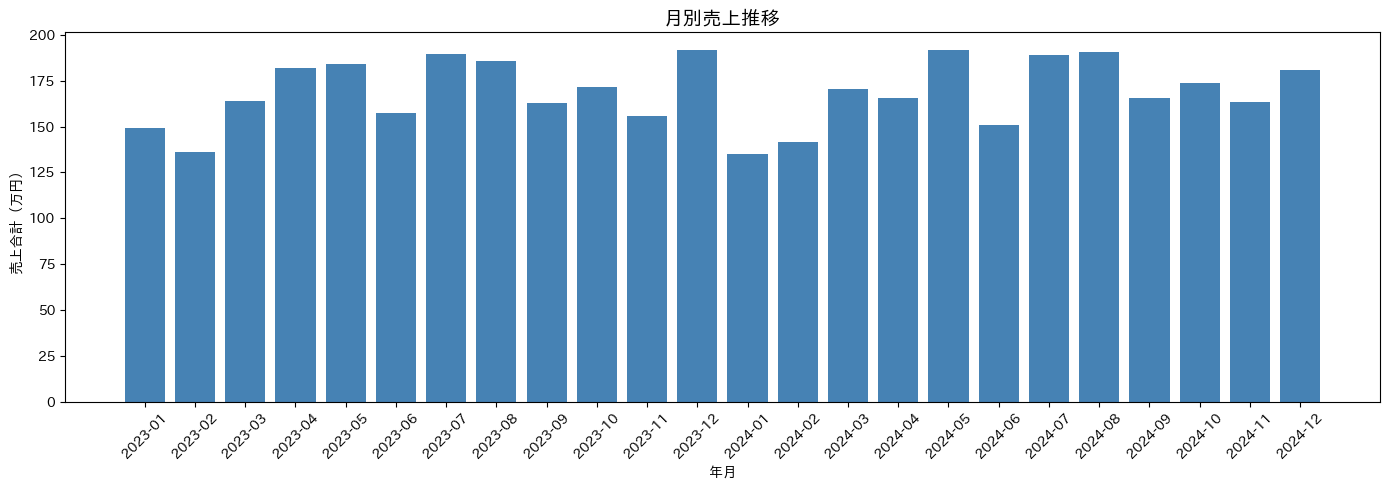

In [17]:
# 月別売上集計
sales_df["year_month"] = sales_df["date"].dt.to_period("M") # 日付データを年月に変換
monthly_sales = sales_df.groupby("year_month")["total"].sum().reset_index() # 月別売上を集計
monthly_sales["year_month"] = monthly_sales["year_month"].astype(str) # 年月を文字列に変換

# グラフ描画
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_sales["year_month"], monthly_sales["total"] / 10000, color="steelblue")
ax.set_title("月別売上推移", fontsize=14)
ax.set_xlabel("年月")
ax.set_ylabel("売上合計（万円）")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

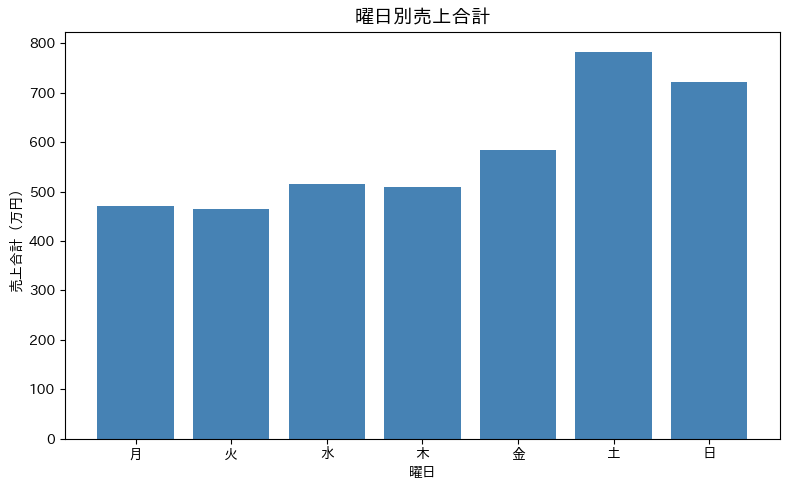

In [18]:
# 曜日別売上集計
sales_df["day_of_week"] = sales_df["date"].dt.dayofweek # 日付データを曜日に変換
day_labels = ["月", "火", "水", "木", "金", "土", "日"] # 曜日のラベル

daily_sales = sales_df.groupby("day_of_week")["total"].sum().reset_index() # 曜日別売上を集計
daily_sales["day_label"] = daily_sales["day_of_week"].map(lambda x: day_labels[x]) # 曜日のラベルを追加

# グラフ描画
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(daily_sales["day_label"], daily_sales["total"] / 10000, color="steelblue")
ax.set_title("曜日別売上合計", fontsize=14)
ax.set_xlabel("曜日")
ax.set_ylabel("売上合計（万円）")
plt.tight_layout()
plt.show()

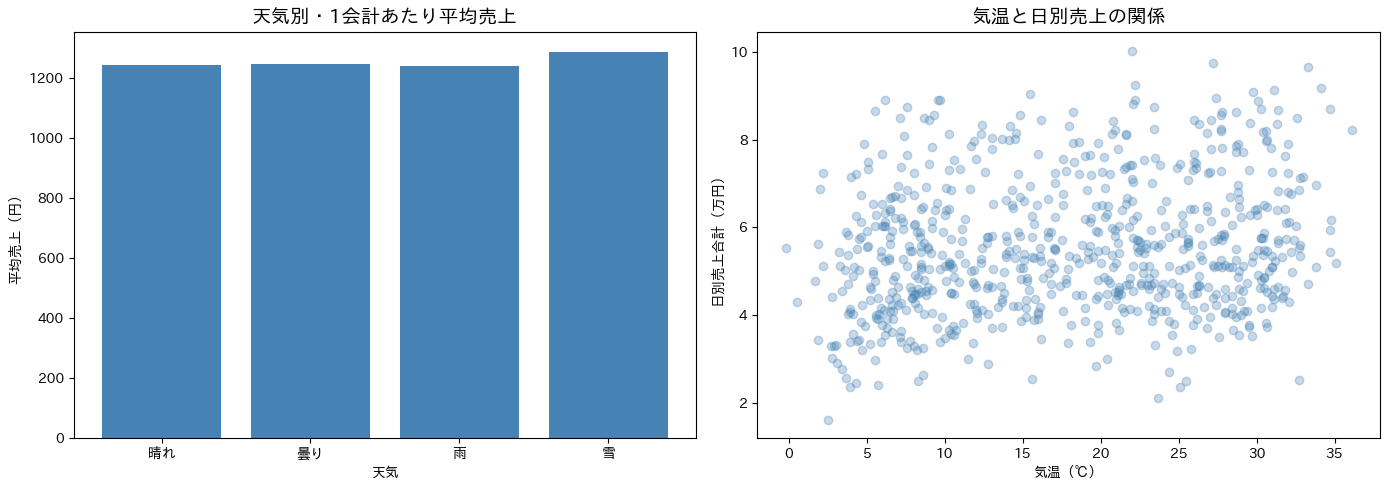

In [19]:
# 天気別売上集計
weather_sales = sales_df.groupby("weather")["total"].agg(["sum", "mean", "count"]).reset_index() # 天気別売上を集計
weather_sales.columns = ["weather", "sum", "mean", "count"] # 列名を変更

# 気温と売上の散布図用データ
# （データが多いので日別に集計してから使う）
daily = sales_df.groupby("date").agg(
    total=("total", "sum"),
    temperature=("temperature", "mean")
).reset_index()

# グラフ描画（1行2列）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：天気別平均売上
axes[0].bar(weather_sales["weather"], weather_sales["mean"], color="steelblue")
axes[0].set_title("天気別・1会計あたり平均売上", fontsize=14)
axes[0].set_xlabel("天気")
axes[0].set_ylabel("平均売上（円）")

# 右：気温と日別売上の散布図
axes[1].scatter(daily["temperature"], daily["total"] / 10000, alpha=0.3, color="steelblue")
axes[1].set_title("気温と日別売上の関係", fontsize=14)
axes[1].set_xlabel("気温（℃）")
axes[1].set_ylabel("日別売上合計（万円）")

plt.tight_layout()
plt.show()

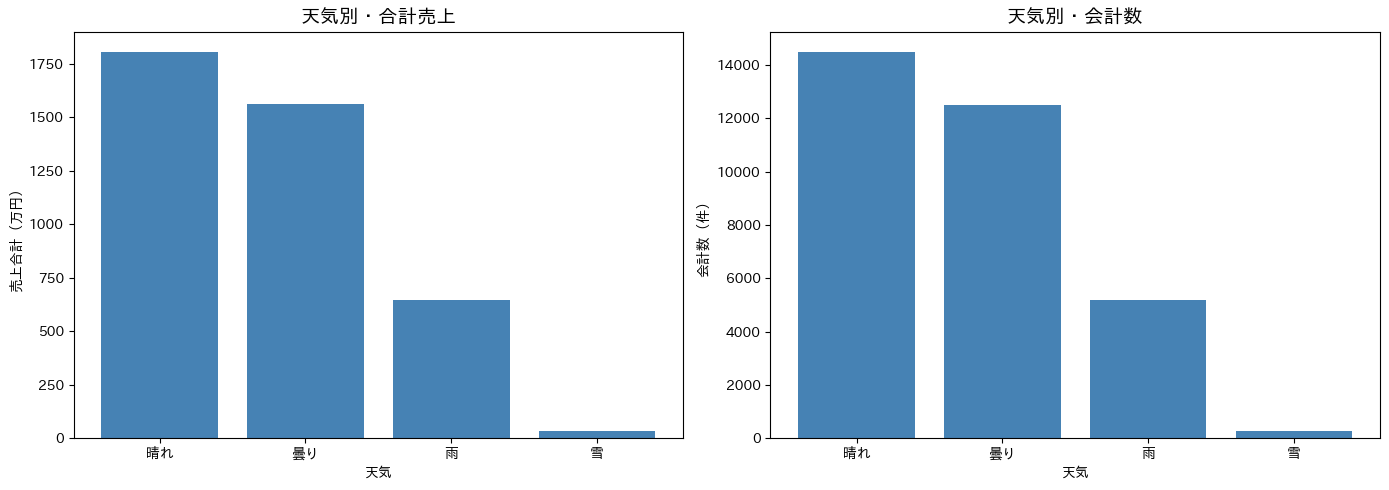

In [20]:
# 天気別・合計売上と会計数も一緒に確認
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：天気別合計売上
axes[0].bar(weather_sales["weather"], weather_sales["sum"] / 10000, color="steelblue")
axes[0].set_title("天気別・合計売上", fontsize=14)
axes[0].set_xlabel("天気")
axes[0].set_ylabel("売上合計（万円）")

# 右：天気別・会計数
axes[1].bar(weather_sales["weather"], weather_sales["count"], color="steelblue")
axes[1].set_title("天気別・会計数", fontsize=14)
axes[1].set_xlabel("天気")
axes[1].set_ylabel("会計数（件）")

plt.tight_layout()
plt.show()

In [21]:
weather_sales

,weather,sum,mean,count
0,晴れ,18055050,1244.918293,14503
1,曇り,15599750,1248.979183,12490
2,雨,6473250,1242.943548,5208
3,雪,342950,1289.285714,266


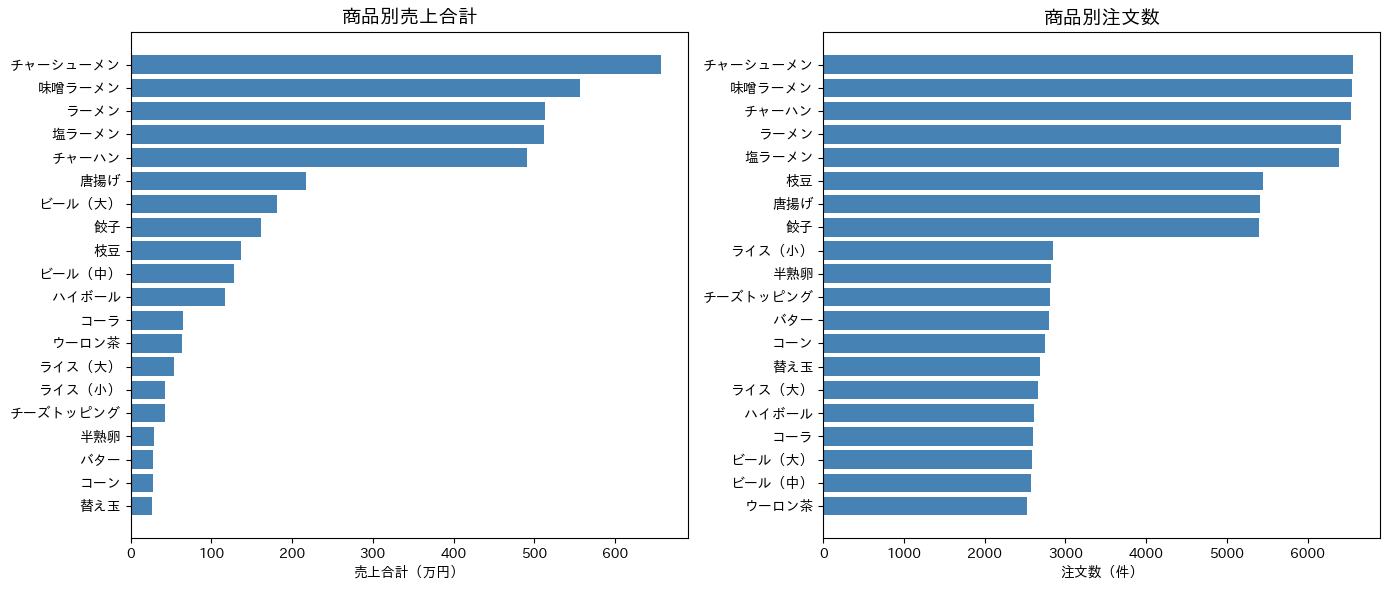

In [22]:
# 商品別売上集計（detail_dfとitems_dfを結合）
item_sales = detail_df.groupby("item_name").agg(
    注文数=("quantity", "sum"),
    売上合計=("price", "sum")
).reset_index().sort_values("売上合計", ascending=False)

# グラフ描画（1行2列）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：商品別売上合計
axes[0].barh(item_sales["item_name"], item_sales["売上合計"] / 10000, color="steelblue")
axes[0].set_title("商品別売上合計", fontsize=14)
axes[0].set_xlabel("売上合計（万円）")
axes[0].invert_yaxis()

# 右：商品別注文数
item_count = item_sales.sort_values("注文数", ascending=False)
axes[1].barh(item_count["item_name"], item_count["注文数"], color="steelblue")
axes[1].set_title("商品別注文数", fontsize=14)
axes[1].set_xlabel("注文数（件）")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

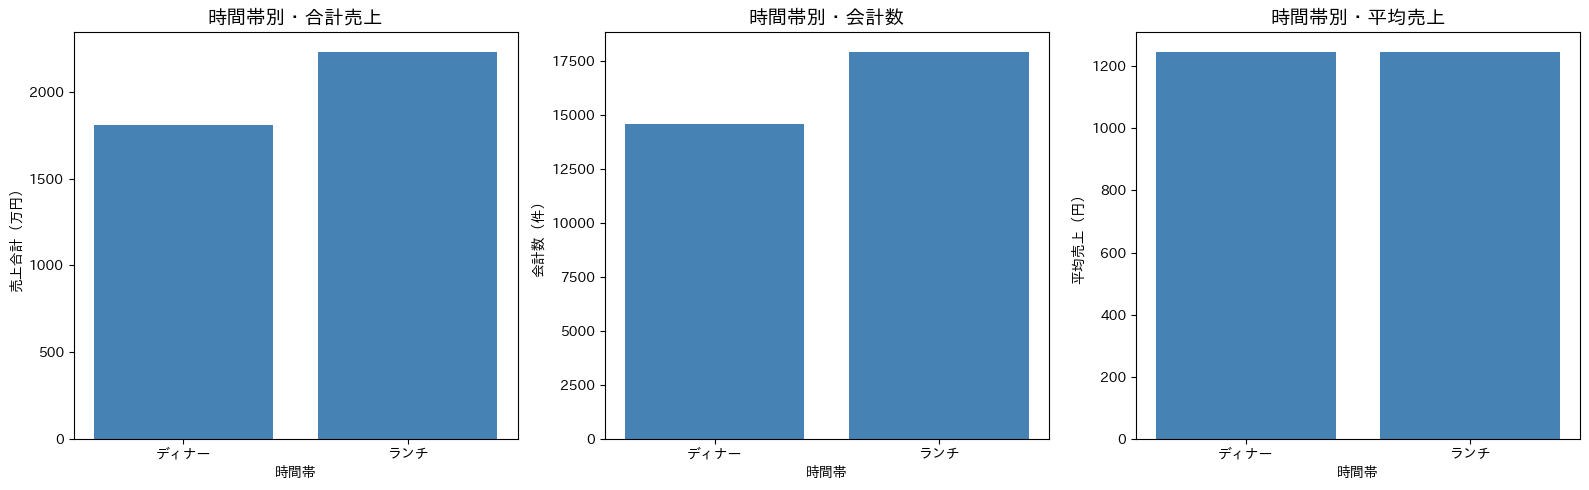

  time_zone      売上合計    会計数         平均売上
0      ディナー  18129800  14556  1245.520747
1       ランチ  22341200  17911  1247.345207


In [23]:
# 時間帯の分類
def get_time_zone(time_str):
    hour = int(time_str.split(":")[0])
    if 11 <= hour <= 14:
        return "ランチ"
    elif 17 <= hour <= 22:
        return "ディナー"
    else:
        return "その他"

sales_df["time_zone"] = sales_df["time"].apply(get_time_zone)

# 時間帯別集計
timezone_sales = sales_df.groupby("time_zone").agg(
    売上合計=("total", "sum"),
    会計数=("sale_id", "count"),
    平均売上=("total", "mean")
).reset_index()

# グラフ描画（1行3列）
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左：時間帯別合計売上
axes[0].bar(timezone_sales["time_zone"], timezone_sales["売上合計"] / 10000, color="steelblue")
axes[0].set_title("時間帯別・合計売上", fontsize=14)
axes[0].set_xlabel("時間帯")
axes[0].set_ylabel("売上合計（万円）")

# 中：時間帯別会計数
axes[1].bar(timezone_sales["time_zone"], timezone_sales["会計数"], color="steelblue")
axes[1].set_title("時間帯別・会計数", fontsize=14)
axes[1].set_xlabel("時間帯")
axes[1].set_ylabel("会計数（件）")

# 右：時間帯別平均売上
axes[2].bar(timezone_sales["time_zone"], timezone_sales["平均売上"], color="steelblue")
axes[2].set_title("時間帯別・平均売上", fontsize=14)
axes[2].set_xlabel("時間帯")
axes[2].set_ylabel("平均売上（円）")

plt.tight_layout()
plt.show()

# 数値も確認
print(timezone_sales)

In [1]:
import requests

# 東京の緯度・経度で7日分の天気予報を取得
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 35.6762,   # 東京の緯度
    "longitude": 139.6503, # 東京の経度
    "daily": [
        "temperature_2m_max",  # 最高気温
        "temperature_2m_min",  # 最低気温
        "precipitation_sum",   # 降水量
        "weathercode"          # 天気コード
    ],
    "timezone": "Asia/Tokyo",
    "forecast_days": 7
}

response = requests.get(url, params=params)
data = response.json()

print(data["daily"])

{'time': ['2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24'], 'temperature_2m_max': [24.3, 28.0, 21.5, 23.0, 22.2, 23.8, 25.1], 'temperature_2m_min': [19.6, 18.9, 19.1, 19.2, 16.7, 15.8, 18.3], 'precipitation_sum': [15.5, 0.2, 3.8, 19.08, 3.4, 1.2, 3.0], 'weathercode': [63, 51, 61, 95, 53, 51, 51]}
